In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
tips = sns.load_dataset("tips")
bill = tips["total_bill"].values
ip = tips["tip"].values

In [4]:
def local_weight(x0,X,tau):
  return np.exp(np.sum((X - x0)**2,axis=1)/(-2*tau*tau))
def local_regression(X,y,tau):
  y_pred = np.zeros(len(X))
  for i in range(len(X)):
    weights=local_weight(X[i],X,tau)
    W = np.diag(weights)
    theta = np.linalg.pinv(X.T@W@X)@(X.T@W@y)
    y_pred[i]= X[i]@theta
  return y_pred



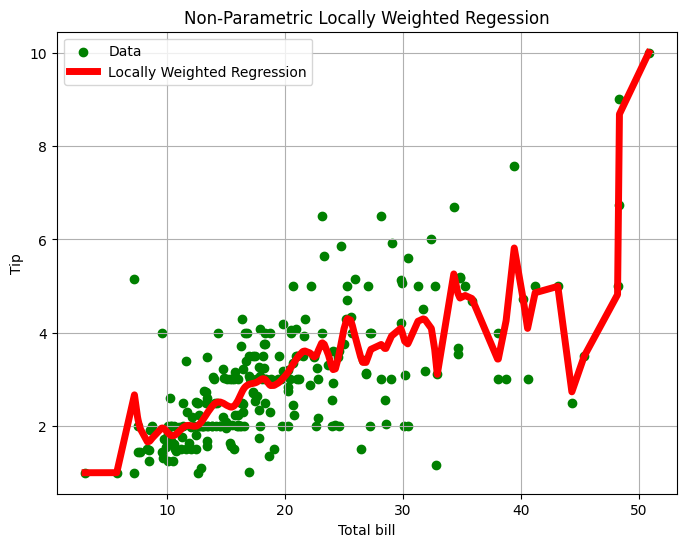

In [5]:
X = np.column_stack((np.ones(len(bill)),bill))
y = ip
tau = 0.5
y_pred = local_regression(X,y,tau)
sort_idx=np.argsort(bill)
xsort=bill[sort_idx]
ysort=y_pred[sort_idx]
plt.figure(figsize=(8,6))
plt.scatter(bill,ip,color="green",label="Data")
plt.plot(xsort,ysort,color="red",linewidth=5,label="Locally Weighted Regression")
plt.xlabel("Total bill")
plt.ylabel("Tip")
plt.title("Non-Parametric Locally Weighted Regession")
plt.legend()
plt.grid(True)
plt.show()